# Gaussian500_53S_5L_Brr500_r2

In [1]:
%pwd

'/home/tzuhsuan/GitHub/QFoam/High-fidelity-Rydberg-control-Z-gates-with-time-optimal-pulses/Gaussian500_53S_5L_BrrX/Gaussian500_53S_5L_Brr500'

In [2]:
import os
import glob
import time
from IPython.display import clear_output

from qutip import *
import math

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

from rdquantum.pulse_shape import Saffman_shape
from rdquantum.fidelity import fidelity
from rdquantum.optimizer.de import de

# Physical system

In [3]:
### Hamiltonian ###
num_levels = 6    # 0, 1, p, r, d, r'

def Hamiltonian(shape_omega1, value_omega2, value_delta1):
    I = qeye(num_levels)

    H_omega1 = (np.pi) * ( basis(num_levels,2)*basis(num_levels,1).dag() 
                          + basis(num_levels,1)*basis(num_levels,2).dag() )

    # Let Omega2, Delta1 and Delta2 be constants.
    value_delta = value_delta1[0]
    H_omega2 = (np.pi) * value_omega2[0] * ( 
        basis(num_levels,3)*basis(num_levels,2).dag() 
        + basis(num_levels,2)*basis(num_levels,3).dag() 
        + basis(num_levels, 5)*basis(num_levels, 2).dag()
        + basis(num_levels, 2)*basis(num_levels, 5).dag()
    )
    H_delta1 = (2*np.pi) * value_delta1[0] * ( basis(num_levels,2)*basis(num_levels,2).dag() )
    # H_delta = (2*np.pi) * value_delta * ( basis(num_levels,3)*basis(num_levels,3).dag() )
    H_deltar2 = (2*np.pi) * (11479) * ( basis(num_levels, 5)*basis(num_levels,5).dag() )

    B = (2*np.pi * 500)
    # Br = B * ( basis(num_levels,3)*basis(num_levels,3).dag() )
    
    # (MHz) Strength of Rydberg states interaction
    # (MHz) Strength of Rydberg states interaction
    Brr = np.sqrt(B) * ( basis(num_levels,3)*basis(num_levels,3).dag() )
    Brr = tensor(Qobj(Brr), Qobj(Brr))
    Brr2 = np.sqrt(B) * ( basis(num_levels,3)*basis(num_levels,5).dag() )
    Brr2 = tensor(Qobj(Brr2), Qobj(Brr2))
    Br2r = np.sqrt(B) * ( basis(num_levels,5)*basis(num_levels,3).dag() )
    Br2r = tensor(Qobj(Br2r), Qobj(Br2r))
    Br2r2 = np.sqrt(B) * ( basis(num_levels,5)*basis(num_levels,5).dag() )
    Br2r2 = tensor(Qobj(Br2r2), Qobj(Br2r2))

    H = [[tensor(H_omega1, I) + tensor(I, H_omega1), shape_omega1], 
         [tensor(H_omega2, I) + tensor(I, H_omega2), '1'], 
         [tensor(H_delta1, I) + tensor(I, H_delta1), '1'],
         [tensor(H_deltar2, I) + tensor(I, H_deltar2), '1'],
         # [tensor(H_delta, I) + tensor(I, H_delta), '1'],
         # [tensor(Br, I) + tensor(I, Br), '1'],
         [Brr, '1'],
         [Brr2, '1'],
         [Br2r, '1'],
         [Br2r2, '1']
        ]

    return H


### Pulse shape omega1(t), omega2(t) and delta1(t) ###
def PulseShape(times, Pulses, T_gate, n_seg):

    def shape_omega1(t, arg):
        # return Saffman_shape(t, Pulses['Omega1'], T_gate, n_seg)
        t = t % T_gate
        t0 = T_gate/2
        tau = 0.165*T_gate
        a = np.exp(- t0**2 / tau**2)
        return Pulses['Omega1'][0] * (np.exp(-(t-t0)**2 / tau**2) - a) / (1-a)

    value_omega2 = Pulses['Omega2']

    value_delta1 = Pulses['Delta1']
    
    # value_delta2 = Pulses['Delta2']
    
    return shape_omega1, value_omega2, value_delta1


### Decay term, c_ops ###
# def Decay(gammap=1/0.155, gammar=1/540):
def Decay(gammap=1/0.11, gammar=1/88):
    # gammap: (1/mu s) population decay rate of the Rydberg state
    # gammar: (1/mu s) population decay rate of the P state
    c_ops = []
    I = qeye(num_levels)
    
    # |p>
    L0p = np.sqrt(0.1354 * gammap) * ( basis(num_levels,0)*basis(num_levels,2).dag() )
    c_ops.append(tensor(Qobj(L0p), I))
    c_ops.append(tensor(I, Qobj(L0p)))

    L1p = np.sqrt(0.2504 * gammap) * ( basis(num_levels,1)*basis(num_levels,2).dag() )
    c_ops.append(tensor(Qobj(L1p), I))
    c_ops.append(tensor(I, Qobj(L1p)))
    
    Ldp = np.sqrt(0.6142 * gammap) * ( basis(num_levels,4)*basis(num_levels,2).dag() )
    c_ops.append(tensor(Qobj(Ldp), I))
    c_ops.append(tensor(I, Qobj(Ldp)))
    
    # |r>
    L0r = np.sqrt(0.053 * gammar) * ( basis(num_levels,0)*basis(num_levels,3).dag() )
    c_ops.append(tensor(Qobj(L0r), I))
    c_ops.append(tensor(I, Qobj(L0r)))

    L1r = np.sqrt(0.053 * gammar) * ( basis(num_levels,1)*basis(num_levels,3).dag() )
    c_ops.append(tensor(Qobj(L1r), I))
    c_ops.append(tensor(I, Qobj(L1r)))

    Ldr = np.sqrt(0.894 * gammar) * ( basis(num_levels,4)*basis(num_levels,3).dag() )
    c_ops.append(tensor(Qobj(Ldr), I))
    c_ops.append(tensor(I, Qobj(Ldr)))
    
    # |r'>
    L0r2 = np.sqrt(0.053 * gammar) * ( basis(num_levels,0)*basis(num_levels,5).dag() )
    c_ops.append(tensor(Qobj(L0r), I))
    c_ops.append(tensor(I, Qobj(L0r)))

    L1r2 = np.sqrt(0.053 * gammar) * ( basis(num_levels,1)*basis(num_levels,5).dag() )
    c_ops.append(tensor(Qobj(L1r), I))
    c_ops.append(tensor(I, Qobj(L1r)))

    Ldr2 = np.sqrt(0.894 * gammar) * ( basis(num_levels,4)*basis(num_levels,5).dag() )
    c_ops.append(tensor(Qobj(Ldr), I))
    c_ops.append(tensor(I, Qobj(Ldr)))

    return c_ops

# Gate Operation

In [4]:
# Gate operation
def GateOp(Pulses, rho_init, targets):
    T_gate = Pulses['T_gate'][0]    # (mu s) Total gate time
    times = np.linspace(0.0, T_gate, 100)
    n_seg = 2*len(Omega1)   # Number of segments

    shape_omega1, value_omega2, value_delta1 = PulseShape(times, Pulses, T_gate, n_seg)
    H = Hamiltonian(shape_omega1, value_omega2, value_delta1)
    c_ops = Decay(1/0.11, 1/88)
    
    results = mesolve(H, rho_init, times, c_ops, targets
                      , options=Options(nsteps=100000, rhs_reuse=False))
    return results

# Outpout

In [5]:
# Omega1 = [1.38, 10.30, 25.54, 42.85, 82.50, 93.35]
# Omega1 = [100]
# Omega2 = [175]
# Delta1 = [300]
# T_gate = [1]
Omega1 = [101.36239308]
Omega2 = [169.81800442]
Delta1 = [499.99969859]
T_gate = [1.5303946]
Pulses = {'Omega1': Omega1, 'Omega2': Omega2, 
          'Delta1': Delta1, 
          'T_gate': T_gate}
# PulsesRange = {'Omega1': [0, 100], 'Omega2': [0, 200], 
#                'Delta1': [0, 1000], 'Delta2': [0, 1000], 
#                'T_gate': [0, 10]}
PulsesRange = {'Omega1': [0, 500], 'Omega2': [0, 500],
               'Delta1': [2000, 2000],
               'T_gate': [0, 10]}

Had = np.zeros((num_levels,num_levels))
Had[0][0] = 1
Had[0][1] = 1
Had[1][0] = 1
Had[1][1] = -1

I = qeye(num_levels)
Had = Qobj(Had/np.sqrt(2))

ket00 = tensor(basis(num_levels,0), basis(num_levels,0))
ket01 = tensor(basis(num_levels,0), basis(num_levels,1))
ket10 = tensor(basis(num_levels,1), basis(num_levels,0))
ket11 = tensor(basis(num_levels,1), basis(num_levels,1))

# Target Bell state, rho_bell = 1/sqrt(2) * (|01> + |10>)
rho0101 = tensor(I, Had) * ket2dm(ket01) * tensor(I, Had)
rho1010 = tensor(I, Had) * ket2dm(ket10) * tensor(I, Had)
rho0110 = tensor(I, Had) * (ket10 * ket01.dag()) * tensor(I, Had)
rho_bell = [rho0101, rho1010, rho0110]

# Initial state, rhoi = |01><01|
rhoi = tensor(Had, Had) * ket2dm(ket01) * tensor(Had, Had)

bell_fidelity = fidelity(GateOp, rhoi, rho_bell)
print(bell_fidelity.get_fidelity(Pulses))

0.9959191270054735


# Analysis

In [6]:
plt.rcParams["figure.figsize"] = [5.5, 3.5]
plt.rcParams["figure.autolayout"] = True
plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.linewidth"] = 2.50

In [7]:
testnpy = np.load("out.npz", allow_pickle=True)
op_pulse = np.load("out-op_pulse.npz", allow_pickle=True)
print(list(testnpy.keys()))
print(list(op_pulse))

['populations', 'fidelity', 'pulses', 'op_fidelity']
['Omega1', 'Omega2', 'Delta1', 'T_gate']


In [8]:
print(op_pulse['Omega1'])
print(op_pulse['Omega2'])
print(op_pulse['Delta1'])
# print(op_pulse['Delta2'])
print(op_pulse['T_gate'])
print(testnpy['op_fidelity'])

[155.85454273]
[234.12294798]
[500.]
[0.53728912]
0.9970401737341198


In [9]:
Omega1 = op_pulse['Omega1']
Omega2 = op_pulse['Omega2']
Delta1 = op_pulse['Delta1']
# Delta2 = op_pulse['Delta2']
T_gate = op_pulse['T_gate']

Pulses = {'Omega1': Omega1, 'Omega2': Omega2, 
          'Delta1': Delta1, 
          'T_gate': T_gate}
PulsesRange = {'Omega1': [0, 100], 'Omega2': [0, 200], 
               'Delta1': [0, 1000], 
               'T_gate': [0, 1]}

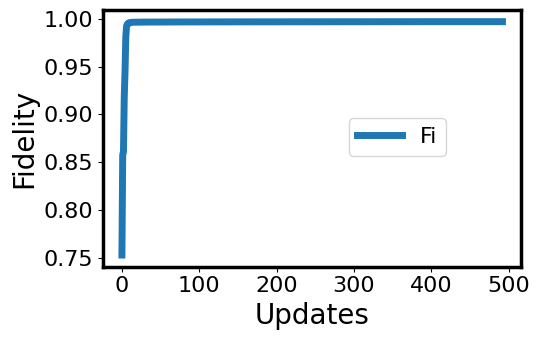

In [10]:
fig, ax1 = plt.subplots()

ax1.plot(testnpy['fidelity'], linewidth=5, label="Fi")

ax1.set_xlabel("Updates", fontsize=20)
ax1.set_ylabel("Fidelity", fontsize=20)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

fig.legend(bbox_to_anchor=(.84, .68), fontsize=16)

## op_pulse

In [11]:
# Pulse shape
T_gate = Pulses['T_gate'][0]         # (mu s) Total gate time
n = 12   # Number of segments
dt = T_gate/n       # (mu s) Duration of each segment
def Pshape(t, pulse_coe):
        ith = int( (t - dt/2) // dt )
        ti = dt/2 + dt*ith
        ti1 = ti + dt
        
        if t < dt/2 or t > (T_gate - dt/2):
            fi = pulse_coe[0]
            fi1 = pulse_coe[0]
            ft = (fi + fi1)/2 

        else:
            if ith < 5:
                ith1 = ith + 1
                fi = pulse_coe[ith]
                fi1 = pulse_coe[ith1]
                ft = ( (fi + fi1)/2 + ( (fi1-fi)/2 ) * math.erf( (5/dt) * ( t - (ti + ti1)/2 ) ) )

            elif ith == 5:
                ith1 = ith
                fi = pulse_coe[ith]
                fi1 = pulse_coe[ith1]
                ft = ( (fi + fi1)/2 + ( (fi1-fi)/2 ) * math.erf( (5/dt) * ( t - (ti + ti1)/2 ) ) )

            elif ith > 5:
                ith1 = ith + 1
                fi = pulse_coe[n-ith-1]
                fi1 = pulse_coe[n-ith1-1]
                ft  = ( (fi + fi1)/2 + ( (fi1-fi)/2 ) * math.erf( (5/dt) * ( t - (ti + ti1)/2 ) ) )

        return ft
def gaussian(t):
    # return Saffman_shape(t, Pulses['Omega1'], T_gate, n_seg)
    t = t % T_gate
    t0 = T_gate/2
    tau = 0.165*T_gate
    a = np.exp(- t0**2 / tau**2)
    return Pulses['Omega1'][0] * (np.exp(-(t-t0)**2 / tau**2) - a) / (1-a)

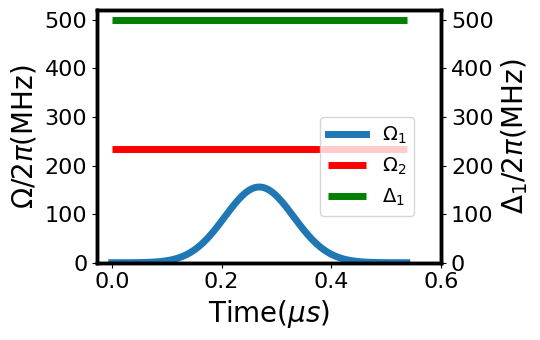

In [12]:
times = np.linspace(0.0, T_gate, 100)

pulse_Omega1 = []
for t in times:
    pulse_Omega1.append( gaussian(t))

fig, ax1 = plt.subplots()

ax1.plot(times, pulse_Omega1, linewidth=5, label=r'$\Omega_1$')
ax1.hlines(y=Omega2[0], xmin=0, xmax=T_gate, linewidth=5, label=r'$\Omega_2$', color='r')

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

ax2 = ax1.twinx()
ax2.hlines(y=Delta1[0], xmin=0, xmax=T_gate, linewidth=5, label=r'$\Delta_1$', color='g')
# ax2.hlines(y=Delta2[0], xmin=0, xmax=T_gate, linewidth=5, label=r'$\Delta_2$', color='y')

ax1.set_xlabel('Time' r'$(\mu s)$', fontsize=20) 
ax1.set_ylabel(r'$\Omega / 2 \pi$' '(MHz)', fontsize=20)
ax2.set_ylabel(r'$\Delta_1 / 2 \pi$' '(MHz)', fontsize=20)
ax1.set_ylim(0, 520)
ax2.set_ylim(0, 520)

xinterval = np.arange(0, 0.71, 0.2)
y1interval = np.arange(0, 520, 100)
ax1.set_xticks(xinterval)
ax1.set_yticks(y1interval)

# plt.title("Fidelity = %.4f" %testnpy['op_fidelity'], fontsize=24)
plt.yticks(fontsize=16)

fig.legend(bbox_to_anchor=(.78, .68), fontsize=14)

# Population Evolution

### $|01\rangle$ / $|10\rangle$

In [13]:
# |01>, |10>
times = np.linspace(0.0, T_gate, 100)
T_gate = Pulses['T_gate'][0]         # (mu s) Total gate time
n_seg = 2*len(Omega1)   # Number of segments

shape_omega1, value_omega2, value_delta1 = PulseShape(times, Pulses, T_gate, n_seg)
H = Hamiltonian(shape_omega1, value_omega2, value_delta1)
c_ops = Decay(1/0.11, 1/88)

# 0, 1, p, r, d
ket0p = tensor(basis(num_levels,0), basis(num_levels,2))
ket0r = tensor(basis(num_levels,0), basis(num_levels,3))
ket0d = tensor(basis(num_levels,0), basis(num_levels,4))
ket0r2 = tensor(basis(num_levels,0), basis(num_levels,5))

P01 = ket2dm(ket01)
P0p = ket2dm(ket0p)
P0r = ket2dm(ket0r)
P0r2 = ket2dm(ket0r2)
P000d = (ket2dm(ket00) + ket2dm(ket0d))

rho_init = ket2dm(ket01)
targets = [P01, P0p, P0r, P0r2, P000d]

result = mesolve(H, rho_init, times, c_ops, targets
                  , options=Options(nsteps=15000, atol=1e-13, rtol=1e-13))

In [ ]:
F_bell = bell_fidelity.get_fidelity(Pulses)
out_r2 = {'op_fidelity': F_bell}
np.savez('out_r2.npz', **out_r2)

print(out_r2)

In [ ]:
out_init01_r2 = {
    "P01": np.log10(result.expect[0]),
    "P0p": np.log10(result.expect[1]),
    "P0r": np.log10(result.expect[2]),
    "P0r'": np.log10(result.expect[3]),
    "P000d": np.log10(result.expect[4])
}
np.savez('out_init01_r2.npz', **out_init01_r2)

In [ ]:
fig, ax = plt.subplots()
ax.plot(times, np.log10(result.expect[0]), linewidth=5) 
ax.plot(times, np.log10(result.expect[1]), linewidth=5)
ax.plot(times, np.log10(result.expect[2]), linewidth=5)
ax.plot(times, np.log10(result.expect[3]), linewidth=5)
ax.plot(times, np.log10(result.expect[4]), linewidth=5)

ax.set_xlabel('Time' r'$(\mu s)$', fontsize=20)
ax.set_ylim(-9, 1)
ax.set_ylabel(r'$log_{10}$' '(population)', fontsize=20) 
ax.legend(("P01", "P0p", "P0r", "P0r'", "P000d"), fontsize=14)

xinterval = np.arange(0, 0.71, 0.2)
ax.set_xticks(xinterval)

# plt.title("Fidelity = %.4f" %bell_fidelity.get_fidelity(Pulses), fontsize=24)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.show()

In [ ]:
# |01>, |10>
times = np.linspace(0.0, T_gate, 100)
n_seg = 2*len(Omega1)   # Number of segments

shape_omega1, value_omega2, value_delta1 = PulseShape(times, Pulses, T_gate, n_seg)
H = Hamiltonian(shape_omega1, value_omega2, value_delta1)
c_ops = Decay(1/0.11, 1/88)

# 0, 1, p, r, d
ket00 = tensor(basis(num_levels,0), basis(num_levels,0))
ket01 = tensor(basis(num_levels,0), basis(num_levels,1))
ket0p = tensor(basis(num_levels,0), basis(num_levels,2))
ket0r = tensor(basis(num_levels,0), basis(num_levels,3))
ket0d = tensor(basis(num_levels,0), basis(num_levels,4))
ket0r2 = tensor(basis(num_levels,0), basis(num_levels,5))

ket10 = tensor(basis(num_levels,1), basis(num_levels,0))
ket11 = tensor(basis(num_levels,1), basis(num_levels,1))
ket1p = tensor(basis(num_levels,1), basis(num_levels,2))
ket1r = tensor(basis(num_levels,1), basis(num_levels,3))
ket1d = tensor(basis(num_levels,1), basis(num_levels,4))
ket1r2 = tensor(basis(num_levels,1), basis(num_levels,5))

ketp0 = tensor(basis(num_levels,2), basis(num_levels,0))
ketpp = tensor(basis(num_levels,2), basis(num_levels,2))
ketp1 = tensor(basis(num_levels,2), basis(num_levels,1))
ketpr = tensor(basis(num_levels,2), basis(num_levels,3))
ketpd = tensor(basis(num_levels,2), basis(num_levels,4))
ketpr2 = tensor(basis(num_levels,2), basis(num_levels,5))

ketr0 = tensor(basis(num_levels,3), basis(num_levels,0))
ketr1 = tensor(basis(num_levels,3), basis(num_levels,1))
ketrp = tensor(basis(num_levels,3), basis(num_levels,2))
ketrr = tensor(basis(num_levels,3), basis(num_levels,3))
ketrd = tensor(basis(num_levels,3), basis(num_levels,4))
ketrr2 = tensor(basis(num_levels,3), basis(num_levels,5))

ketd0 = tensor(basis(num_levels,4), basis(num_levels,0))
ketd1 = tensor(basis(num_levels,4), basis(num_levels,1))
ketdp = tensor(basis(num_levels,4), basis(num_levels,2))
ketdr = tensor(basis(num_levels,4), basis(num_levels,3))
ketdd = tensor(basis(num_levels,4), basis(num_levels,4))
ketdr2 = tensor(basis(num_levels,4), basis(num_levels,5))

ketr20 = tensor(basis(num_levels,5), basis(num_levels,0))
ketr21 = tensor(basis(num_levels,5), basis(num_levels,1))
ketr2p = tensor(basis(num_levels,5), basis(num_levels,2))
ketr2r = tensor(basis(num_levels,5), basis(num_levels,3))
ketr2d = tensor(basis(num_levels,5), basis(num_levels,4))
ketr2r2 = tensor(basis(num_levels,5), basis(num_levels,5))

P11 = ket2dm(ket11)
Ppp = ( ket2dm(ketpp)
       + ket2dm(ketp0) + ket2dm(ketp1) + ket2dm(ketpr) + ket2dm(ketpd) + ket2dm(ketpr2)
       + ket2dm(ket0p) + ket2dm(ket1p) + ket2dm(ketrp) + ket2dm(ketdp) + ket2dm(ketr2p)
      )
P1rr1 = ket2dm(ket1r) + ket2dm(ketr1)
Prr = ket2dm(ketrr)
Pr2r2 = ( ket2dm(ketrr2)
        + ket2dm(ketr20) + ket2dm(ketr21) + ket2dm(ketr2p) + ket2dm(ketr2r) + ket2dm(ketr2d)
        + ket2dm(ket0r2) + ket2dm(ket1r2) + ket2dm(ketpr2) + ket2dm(ketrr2) + ket2dm(ketdr2)
       )
P00dd = ( 
    ket2dm(ket00) + ket2dm(ket01) + ket2dm(ket0p) + ket2dm(ket0r) + ket2dm(ket0d) + ket2dm(ket0r2)
    + ket2dm(ket10) + ket2dm(ketp0) + ket2dm(ketr0) + ket2dm(ketd0) + ket2dm(ketr20)
    + ket2dm(ketd1) + ket2dm(ketdp) + ket2dm(ketdr) + ket2dm(ketdd) + ket2dm(ketdr2)
    + ket2dm(ket1d) + ket2dm(ketpd) + ket2dm(ketrd) + ket2dm(ketr2d)
)

rho_init = ket2dm(ket11)
targets = [P11, Ppp, P1rr1, Prr, Pr2r2, P00dd]

result = mesolve(H, rho_init, times, c_ops, targets, options=Options(nsteps=15000, atol=1e-13, rtol=1e-13))

In [ ]:
print(bell_fidelity.get_fidelity(Pulses))

In [ ]:
out_init11_r2 = {
    "P11": np.log10(result.expect[0]),
    "Ppp": np.log10(result.expect[1]),
    "P1rr1": np.log10(result.expect[2]),
    "Prr": np.log10(result.expect[3]),
    "Pr'r'": np.log10(result.expect[4]),
    "P00dd": np.log10(result.expect[5])
}
np.savez('out_init11_r2.npz', **out_init11_r2)

In [ ]:
fig, ax = plt.subplots()
ax.plot(times, np.log10(result.expect[0]), linewidth=5) 
ax.plot(times, np.log10(result.expect[1]), linewidth=5)
ax.plot(times, np.log10(result.expect[2]), linewidth=5)
ax.plot(times, np.log10(result.expect[3]), linewidth=5, color='tab:purple')
ax.plot(times, np.log10(result.expect[4]), linewidth=5, color='tab:gray')
ax.plot(times, np.log10(result.expect[5]), linewidth=5, color='tab:red')

ax.set_xlabel('Time' r'$(\mu s)$', fontsize=20)
ax.set_ylim(-8, 1)
# ax.set_ylabel(r'$log_{10}$' '(population)', fontsize=20) 
ax.legend(("P11", "Ppp", "P1rr1", "Prr", "Pr2r2", "P00dd"), fontsize=14)

xinterval = np.arange(0, 0.71, 0.2)
ax.set_xticks(xinterval)

# plt.title("Fidelity = %.4f" %bell_fidelity.get_fidelity(Pulses), fontsize=24)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.show()